<a href="https://colab.research.google.com/github/linhle123578/linhle31231023748/blob/main/N7_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

📈 Evaluation Metrics (Test Set):
AUC      : 0.998
Accuracy : 0.986
F1 Score : 0.992
Precision: 0.991
Recall   : 0.993
MCC      : 0.927


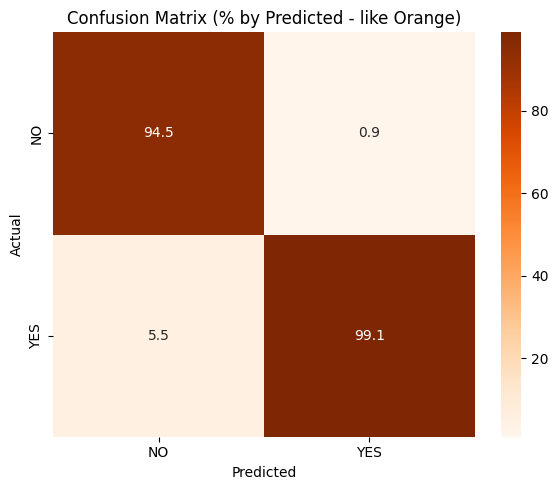

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

✅ Độ chính xác trên 500 mẫu được tách từ test: 0.9940


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, accuracy_score, roc_auc_score,
                             f1_score, precision_score, recall_score, matthews_corrcoef)
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# === 1. Đọc dữ liệu
df = pd.read_excel('/content/Nhóm 7_ dataset.xlsx')
df = df.dropna()

# === 2. Tách X, y
X = df.drop(columns=['LUNG_CANCER'])
y = df['LUNG_CANCER']

# === 3. Mã hóa nhãn
if y.dtype == 'object':
    le_y = LabelEncoder()
    y = pd.Series(le_y.fit_transform(y), index=y.index)
else:
    le_y = None
    y = pd.Series(y, index=y.index)

# === 4. Mã hóa các cột object trong X
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = LabelEncoder().fit_transform(X[col])

# === 5. Train-test split (70/30)
X_train, X_test_full, y_train, y_test_full = train_test_split(
    X, y, test_size=0.3, random_state=42)

# === 6. Tách 500 mẫu từ test để dự đoán riêng
X_test_full = X_test_full.copy()
y_test_full = y_test_full.copy()

X_predict = X_test_full.sample(n=500, random_state=0)
y_predict_true = y_test_full.loc[X_predict.index]

X_test = X_test_full.drop(index=X_predict.index)
y_test = y_test_full.drop(index=X_predict.index)

# === 7. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_predict_scaled = scaler.transform(X_predict)

# === 8. Xây dựng mô hình ANN
model = Sequential([
    Dense(12, activation='relu', input_dim=X_train_scaled.shape[1]),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# === 9. Huấn luyện mô hình
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=10,
                    validation_split=0.1, verbose=0)

# === 10. Đánh giá trên tập test (phần còn lại)
loss, accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

y_pred_prob = model.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\n📈 Evaluation Metrics (Test Set):")
print(f"AUC      : {roc_auc_score(y_test, y_pred_prob):.3f}")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall   : {recall_score(y_test, y_pred):.3f}")
print(f"MCC      : {matthews_corrcoef(y_test, y_pred):.3f}")

# === 11. Ma trận nhầm lẫn (theo % cột dự đoán)
cm = confusion_matrix(y_test, y_pred, normalize='pred') * 100
labels = le_y.classes_ if le_y else ['0', '1']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt=".1f", cmap='Oranges',
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix (% by Predicted - like Orange)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png')  # Lưu hình
plt.show()

# === 12. Dự đoán trên 500 mẫu đã tách
y_pred_500_prob = model.predict(X_predict_scaled).ravel()
y_pred_500 = (y_pred_500_prob >= 0.5).astype(int)
acc_500 = accuracy_score(y_predict_true, y_pred_500)

print(f"\n✅ Độ chính xác trên 500 mẫu được tách từ test: {acc_500:.4f}")

# === 13. Xuất kết quả 500 mẫu
df_output = X_predict.copy()
df_output['Actual'] = y_predict_true
df_output['Predicted'] = y_pred_500
df_output.to_excel('/content/du_doan_500_tu_test.xlsx', index=False)


# === 14. Lưu các chỉ số đánh giá ra file Excel
metrics_test = {
    'Metric': ['AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall', 'MCC'],
    'Value': [
        roc_auc_score(y_test, y_pred_prob),
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        matthews_corrcoef(y_test, y_pred)
    ]
}

metrics_500 = {
    'Metric': ['Accuracy_500_samples'],
    'Value': [acc_500]
}

df_metrics_test = pd.DataFrame(metrics_test)
df_metrics_500 = pd.DataFrame(metrics_500)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

with pd.ExcelWriter('/content/evaluation_results.xlsx') as writer:
    df_metrics_test.to_excel(writer, sheet_name='Metrics_Test', index=False)
    df_metrics_500.to_excel(writer, sheet_name='Metrics_500_samples', index=False)
    cm_df.to_excel(writer, sheet_name='Confusion_Matrix')


# === 15. Lưu dữ liệu training đã xử lý
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
if le_y:
    y_train_labels = le_y.inverse_transform(y_train)
    X_train_df['LUNG_CANCER'] = y_train_labels
else:
    X_train_df['LUNG_CANCER'] = y_train

X_train_df.to_excel('/content/training_data_processed.xlsx', index=False)

